# Introduction to Pipelines

## Set the path to the ERA5lowres archive as an environment variable

Make sure to set the `ERA5LOWRES` environment variable to make the ERA5 low-resolution archive findable on your system.

If you are at one of the following organisations, you can modify the following cell as follows:

* for NCI (Australia): `%env ERA5LOWRES=/g/data/wb00/NCI-Weatherbench/5.625deg`

* for NIWA (New Zealand): `%env ERA5LOWRES=/nesi/nobackup/niwa00004/riom/weatherbench/5.625deg`

* for the Met Office (UK): `%env ERA5LOWRES=/data/users/infolab/weatherbench/5.625deg`

If you are at another facility, you will need to download the 5.625deg ERA5 dataset from Weatherbench. Instructions to do so can be found in the `Downloading_ERA5.ipynb` notebook. Then set the environment variable to the location of your local copy. 

In [ ]:
# NCI: 
# %env ERA5LOWRES=/g/data/wb00/NCI-Weatherbench/5.625deg

# NIWA:
# %env ERA5LOWRES=/nesi/nobackup/niwa00004/riom/weatherbench/5.625deg

# Met Office:
%env ERA5LOWRES=/data/users/infolab/weatherbench/5.625deg

env: ERA5LOWRES=/data/users/infolab/weatherbench/5.625deg


In [25]:
# Here we import the same models as from the previous example
import pyearthtools.data
import pyearthtools.tutorial

In [26]:
# Now we import the pipeline model which is new in this example
import pyearthtools.pipeline

## Create a data preparation pipeline. 

We can use pipelines to create a reproducable and explainable process to prepare data for specific tasks. 
Pipelines could also be shared as templates to complete similar work. 

The pipeline below:
1. Selects the 'u' and 'v' wind variables.
2. Selects the 'geopotential' and 'vorticity' atmospheric variables. 
3. Merges these into a single dataset. 
4. Sorts the variables into a specified order -> 'msl', '10u', '10v', '2t', 'geopotential', 'vorticity'.
5. Applies a Coordinate Transformation to ensure latitude is formated as 0-360 degrees (not -180-180 degrees) using the StandardLongitude class, and
6. Reverses the data by 'level' coordinate using the ReIndex class. 


In [ ]:
data_preparation = pyearthtools.pipeline.Pipeline(
    (
        pyearthtools.data.archive.era5lowres(['u', 'v']), 
        pyearthtools.data.archive.era5lowres(['geopotential', 'vorticity']), 
    ),
    pyearthtools.pipeline.operations.xarray.Merge(),
    pyearthtools.pipeline.operations.xarray.Sort(['msl', '10u', '10v', '2t', 'geopotential', 'vorticity']),
    pyearthtools.pipeline.operations.Transforms(
        apply=pyearthtools.data.transforms.coordinates.StandardLongitude(type='0-360') + pyearthtools.data.transforms.coordinates.ReIndex(level='reversed')
    ),

    # These methods will be explained when we create a pipeline for machine learning. 
    # pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten('level'),
    # pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    # pyearthtools.pipeline.operations.numpy.reshape.Squeeze(1),
)


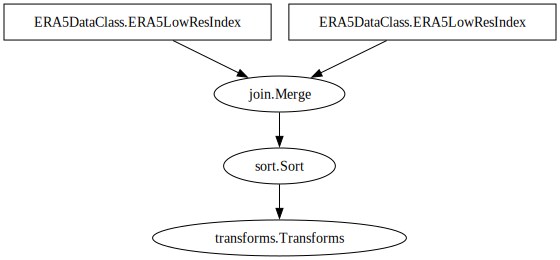

In [ ]:
# Inspect the data_preparation pipeline which also visualises the pipeline as a graph. 
data_preparation

In [34]:
# Use the pipeline to create a sample for a specific date.
sample = data_preparation['1984-01-01'] 
sample

<xarray.Dataset> Size: 10MB
Dimensions:    (latitude: 32, longitude: 64, level: 13, time: 24)
Coordinates:
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * level      (level) int32 52B 1000 925 850 700 600 500 ... 250 200 150 100 50
  * time       (time) datetime64[ns] 192B 1984-01-01 ... 1984-01-01T23:00:00
Data variables:
    u          (time, level, latitude, longitude) float32 3MB dask.array<chunksize=(24, 6, 19, 39), meta=np.ndarray>
    v          (time, level, latitude, longitude) float32 3MB dask.array<chunksize=(24, 6, 19, 39), meta=np.ndarray>
    vo         (time, level, latitude, longitude) float32 3MB dask.array<chunksize=(24, 6, 19, 39), meta=np.ndarray>
    z          (time, level, latitude, longitude) float32 3MB dask.array<chunksize=(24, 6, 19, 39), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6

In [35]:
# Inspect vo DataArray variable.
sample.vo

<xarray.DataArray 'vo' (time: 24, level: 13, latitude: 32, longitude: 64)> Size: 3MB
dask.array<getitem, shape=(24, 13, 32, 64), dtype=float32, chunksize=(24, 7, 19, 39), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 256B -87.19 -81.56 -75.94 ... 81.56 87.19
  * longitude  (longitude) float64 512B 0.0 5.625 11.25 ... 343.1 348.8 354.4
  * level      (level) int32 52B 1000 925 850 700 600 500 ... 250 200 150 100 50
  * time       (time) datetime64[ns] 192B 1984-01-01 ... 1984-01-01T23:00:00
Attributes:
    units:          s**-1
    long_name:      Vorticity (relative)
    standard_name:  atmosphere_relative_vorticity